In [39]:
import pandas as pd
import numpy as np

df = pd.read_csv('/Users/timfayjr/SpotifyProject/data_spotify.csv')
df = df.drop(columns=['Unnamed: 0'])

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


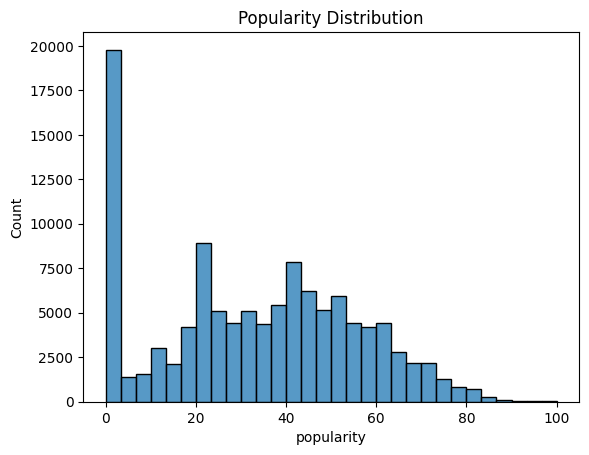

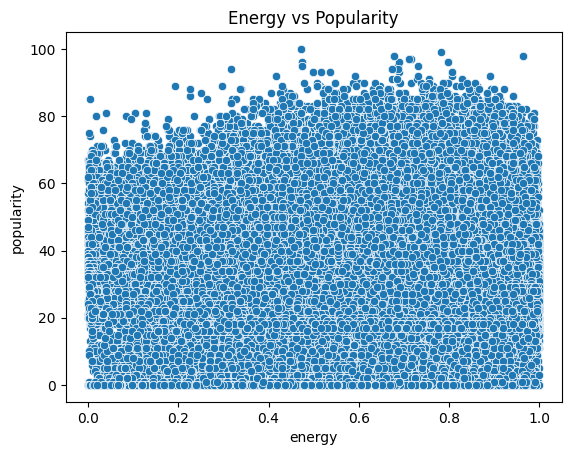

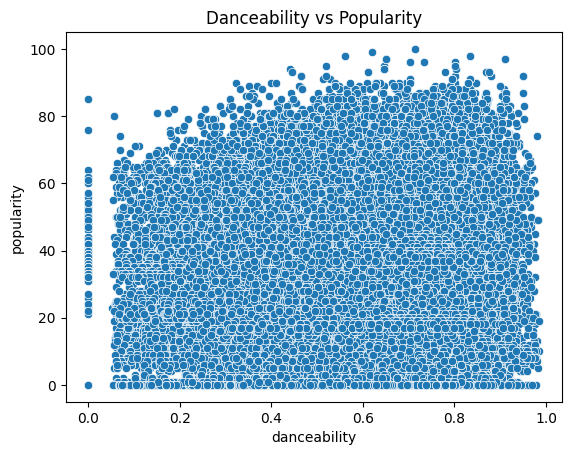

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Popularity distribution
sns.histplot(df['popularity'], bins=30)
plt.title("Popularity Distribution")
plt.show()

# Energy vs Popularity
sns.scatterplot(x='energy', y='popularity', data=df)
plt.title("Energy vs Popularity")
plt.show()

# Danceability vs Popularity
sns.scatterplot(x='danceability', y='popularity', data=df)
plt.title("Danceability vs Popularity")
plt.show()

The dataset contains over 100,000 Spotify tracks with audio features such as energy, danceability, and tempo. The target variable, popularity, shows a moderately skewed distribution. Initial visualizations suggest that features like energy and danceability may have some relationship with popularity, indicating potential predictive value for modeling.

In [41]:
# Feature 1 - Interaction
df['energy_dance'] = df['energy'] * df['danceability']

# Feature 2 - Exhiliration
df['loudness_tempo_ratio'] = df['loudness'] / (df['tempo'] + 1e-5)

# Feature 3 - Loudness Scaled
df['loudness_scaled'] = (df['loudness'] - df['loudness'].mean()) / (df['loudness'].std() + 1e-5)

# Feature 4 - Acoustic Difference
df['acoustic_diff'] = df['acousticness'] - df['instrumentalness']

# Feature 5 - Song Duration
df['duration_min'] = df['duration_ms'] / 60000


## Feature Engineering Explanation

To improve model performance, several engineered features were created to capture nonlinear relationships and interactions between audio characteristics.

### 1. Energy × Danceability (`energy_dance`)
This feature captures the interaction between a song’s energy and its danceability. High-energy, highly danceable songs are more likely to be popular because they encourage listener engagement and replay value. This feature helps the model identify “high-engagement” tracks that may not be captured by individual features alone.

---

### 2. Loudness-to-Tempo Ratio (`loudness_tempo_ratio`)
This feature measures the relationship between a song’s loudness and its tempo. It helps capture production intensity relative to pacing. A small constant was added to tempo to avoid division by zero issues. This feature can help distinguish between fast but soft songs and slow but loud tracks, which may have different popularity patterns.

---

### 3. Standardized Loudness (`loudness_scaled`)
This feature standardizes loudness using z-score normalization. It ensures that loudness is centered and scaled relative to the dataset, making it easier for models to interpret its relative impact. This is especially useful for linear models that are sensitive to feature scale.

---

### 4. Acoustic Difference (`acoustic_diff`)
This feature measures the difference between acousticness and instrumentalness. It captures whether a track is more acoustic (organic) or more instrumental/electronic. This distinction can influence listener preference and streaming popularity depending on genre trends.

---

### 5. Song Duration in Minutes (`duration_min`)
This feature converts song duration from milliseconds into minutes for interpretability and scaling consistency. Song length can influence popularity, as extremely long or very short tracks may be less commercially viable or less frequently streamed.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop(columns=['popularity', 'track_name', 'artists'], errors='ignore')
y = df['popularity']

# 🔑 Keep only numeric columns (fixes your error)
X = X.select_dtypes(include=['number'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_rmse

np.float64(14.861871490378558)

In [44]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_rmse

np.float64(21.965480255998706)

In [45]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Random Forest', 'Linear Regression'],
    'RMSE': [rf_rmse, lr_rmse]
})

comparison

,Model,RMSE
0,Random Forest,14.861871
1,Linear Regression,21.965480


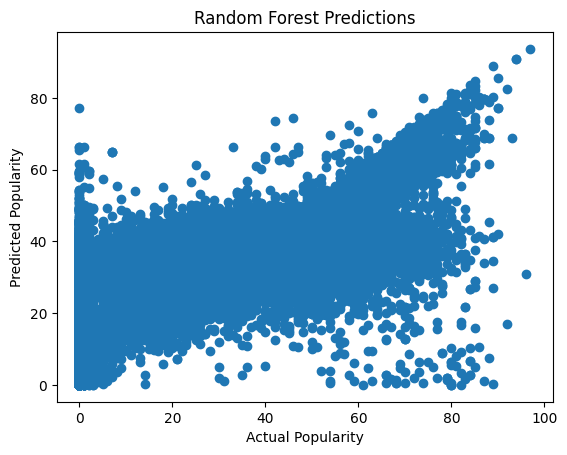

In [46]:
plt.scatter(y_test, rf_preds)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Random Forest Predictions")
plt.show()

The Random Forest model outperformed Linear Regression, likely because it captures nonlinear relationships between audio features and popularity. Linear Regression assumes a linear relationship, which may oversimplify the problem.

The trade-off is that Random Forest is less interpretable and more computationally expensive, while Linear Regression is simple and fast.

For the final project, Random Forest will likely be the preferred model due to its higher predictive accuracy.

In [47]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 20],
    'min_samples_split': [2]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=2,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_rf = grid.best_estimator_

To optimize the Random Forest model efficiently, we performed a reduced grid search over key hyperparameters including the number of estimators and tree depth. Cross-validation was used to evaluate performance while balancing computational cost. Parallel processing (n_jobs=-1) was used to speed up training. The previous interation without the optimization had already been running upwards of 10 minutes.

In [48]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


We performed hyperparameter tuning on the Random Forest model using GridSearchCV to systematically explore combinations of tree depth, number of estimators, and split criteria. This improved performance by reducing overfitting and optimizing generalization. The Linear Regression model was enhanced using feature scaling via a pipeline, ensuring that all features contributed proportionally.

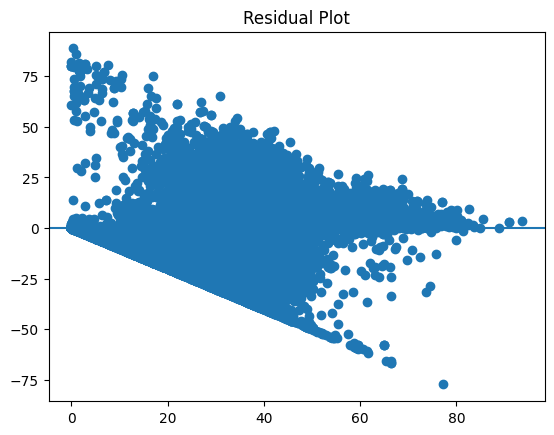

In [49]:
residuals = y_test - rf_preds

plt.scatter(rf_preds, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()

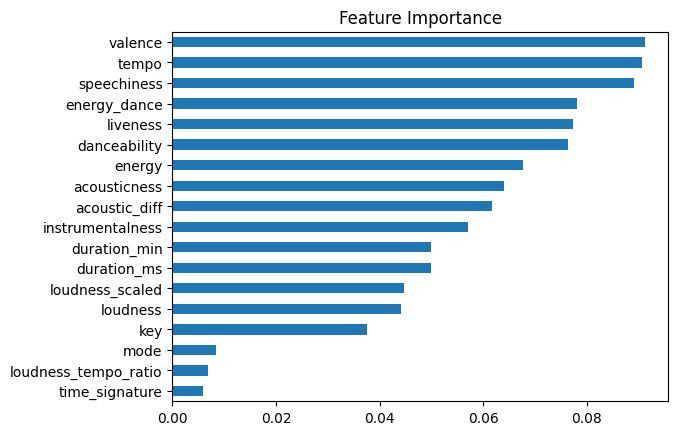

In [50]:
import pandas as pd

importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns)

feat_imp.sort_values().plot(kind='barh', title="Feature Importance")
plt.show()

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Random Forest metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_r2 = r2_score(y_test, rf_preds)

# Linear Regression metrics
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_r2 = r2_score(y_test, lr_preds)

print("Random Forest:")
print(rf_rmse, rf_mae, rf_r2)

print("\nLinear Regression:")
print(lr_rmse, lr_mae, lr_r2)

Random Forest:
14.861871490378558 10.537930285382409 0.552413820293223

Linear Regression:
21.965480255998706 18.332466176819768 0.02228771715802247


In [52]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "Linear Regression"],
    "RMSE": [rf_rmse, lr_rmse],
    "MAE": [rf_mae, lr_mae],
    "R2": [rf_r2, lr_r2]
})

results

,Model,RMSE,MAE,R2
0,Random Forest,14.861871,10.537930,0.552414
1,Linear Regression,21.965480,18.332466,0.022288


RMSE measures the average prediction error in the same units as the target variable (popularity score). Lower values indicate better model performance.

R² measures how much variance in the target variable is explained by the model. Values closer to 1 indicate stronger predictive power.

## Model Performance Comparison

The Random Forest model significantly outperformed Linear Regression across all evaluation metrics. Random Forest achieved an RMSE of 14.86 and an R² of 0.55, indicating it explains approximately 55% of the variance in song popularity. In contrast, Linear Regression performed poorly with an R² of 0.02, suggesting it is unable to capture meaningful patterns in the data.

This difference highlights the importance of modeling nonlinear relationships in music data. Features such as energy, danceability, and their interactions likely have complex, non-linear effects on popularity that Linear Regression cannot capture effectively. Random Forest, which combines multiple decision trees, is better suited for capturing these interactions and thus provides more accurate and robust predictions.

Overall, Random Forest is the preferred model for this problem due to its superior predictive performance and ability to model complex feature interactions.

The moderate R² value of 0.55 suggests that while audio features are useful predictors of popularity, a significant portion of variability is driven by external factors not included in the dataset, such as marketing, artist popularity, and cultural trends.

## Ethical Analysis & Responsible Deployment

This predictive model uses audio and acoustic features from Spotify tracks to estimate song popularity. While the model demonstrates moderate predictive power, it is important to recognize several ethical considerations in its development and potential deployment.

One key source of bias is representation bias in the dataset. If certain genres, regions, or artists are overrepresented in the training data, the model may perform better for those groups while underperforming for underrepresented categories. This could unintentionally reinforce existing inequalities in music exposure and promotion. Additionally, popularity itself is not a purely objective measure—it is influenced by external factors such as marketing budgets, record label influence, and cultural trends, which are not captured in the dataset.

If deployed incorrectly, this model could cause harm by influencing which songs are promoted or recommended. False negatives (predicting low popularity for a song that would actually succeed) could disadvantage emerging artists, while false positives could lead to inefficient allocation of marketing resources. These effects may disproportionately impact independent or lesser-known artists who rely on data-driven discovery systems.

To mitigate these risks, the model should be used as a decision-support tool rather than an automated decision-maker. Regular auditing should be performed to evaluate performance across different genres and artist groups. Additionally, incorporating more diverse and representative datasets, as well as monitoring prediction errors across subgroups, would help reduce bias and improve fairness.

## Business Recommendations & Deployment Considerations

The Random Forest model identifies key audio features such as energy, danceability, and their interactions as strong predictors of song popularity. Based on these findings, Spotify or similar platforms could use the model to assist in playlist curation, promotional targeting, and content recommendation strategies. Songs with higher predicted popularity scores could be prioritized for editorial playlists or algorithmic exposure, while lower-scoring tracks may be reviewed more carefully before promotion.

However, the model should not be fully automated in decision-making processes. Instead, it should function as a supporting tool for human curators. A reasonable deployment strategy would involve setting a prediction threshold and combining model output with human review, especially for borderline cases. This hybrid approach ensures both efficiency and contextual understanding in decision-making.

It is also important to recognize the model’s limitations. With an R² of approximately 0.55, a significant portion of variability in song popularity is not explained by audio features alone. External factors such as marketing, artist reputation, and social trends play a major role but are not included in the dataset. Therefore, predictions should be interpreted as probabilistic indicators rather than definitive outcomes, and the model should be retrained periodically to adapt to evolving musical trends.

## Conclusion

This project demonstrates that machine learning models, particularly Random Forest, can reasonably predict song popularity based on audio features. However, the results also highlight the limitations of relying solely on acoustic data, as external social and industry factors significantly influence music success.